In [1]:
import mne
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt
import os

In [2]:
# ✅ 데이터 경로
base_dir = r"C:\Users\owner\Desktop\dataset\derivatives"
subjects = [f"sub-{str(i).zfill(3)}" for i in range(1, 89)]
labels_dict = {"Control": 0, "AD": 1}

In [3]:
eeg_data = []
labels = []

In [4]:
# ✅ 데이터 로드 및 전처리
print("🔄 EEG 데이터 로드 중...")
for subject in subjects:
    file_path = os.path.join(base_dir, subject, "eeg", f"{subject}_task-eyesclosed_eeg.set")
    if os.path.exists(file_path):
        print(f"✅ {subject} 데이터 로드")
        raw = mne.io.read_raw_eeglab(file_path, preload=True)
        raw.resample(128)
        raw.filter(1., 40.)
        data = raw.get_data()
        data = np.transpose(data, (1, 0))  # (time, channels)

        # ✅ 10초 데이터만 사용
        if data.shape[0] >= 1280:
            data = data[:1280, :]
        else:
            print(f"⚠ {subject}: 데이터 길이 부족 ({data.shape[0]} < 1280), 스킵")
            continue

        eeg_data.append(data)
        subject_num = int(subject.split("-")[1])
        labels.append(labels_dict["AD"] if subject_num % 2 == 0 else labels_dict["Control"])
    else:
        print(f"❌ {file_path} 없음")

🔄 EEG 데이터 로드 중...
✅ sub-001 데이터 로드
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)

✅ sub-002 데이터 로드


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:    0.0s finished


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)

✅ sub-003 데이터 로드


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:    0.0s finished
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37396\4177647682.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)

✅ sub-004 데이터 로드


...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:    0.0s finished
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37396\4177647682.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)

✅ sub-088 데이터 로드


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:    0.1s finished
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_37396\4177647682.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  19 out of  19 | elapsed:    0.1s finished


In [5]:
if len(eeg_data) == 0:
    raise ValueError("❌ EEG 데이터가 없습니다. 경로를 확인하세요.")

In [6]:
eeg_data_array = np.stack(eeg_data)  # (samples, time, channels)
labels_array = np.array(labels)

In [7]:
print("📊 데이터 shape:", eeg_data_array.shape, "라벨 shape:", labels_array.shape)

📊 데이터 shape: (88, 1280, 19) 라벨 shape: (88,)


In [8]:
# -------------------------------
# ✅ PyTorch 데이터셋 클래스
# -------------------------------
class EEGDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [9]:
# -------------------------------
# ✅ CNN+RNN 모델 (Conv 출력 자동 계산)
# -------------------------------
class CNN_RNN_Model(nn.Module):
    def __init__(self):
        super(CNN_RNN_Model, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1)
        self.pool = nn.MaxPool2d((2, 2))

        # ✅ dummy 입력으로 LSTM input_size 계산
        dummy_input = torch.zeros(1, 1, 1280, 19)
        dummy_output = self.pool(torch.relu(self.conv1(dummy_input)))
        time_steps = dummy_output.shape[2]
        feature_size = dummy_output.shape[1] * dummy_output.shape[3]  # channels * features
        self.lstm_input_size = feature_size
        print(f"✅ LSTM 입력 feature size: {self.lstm_input_size}, time_steps: {time_steps}")

        self.lstm = nn.LSTM(input_size=self.lstm_input_size, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 2)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, time, channels)
        x = self.pool(torch.relu(self.conv1(x)))
        # ✅ (batch, channels, time, features) → (batch, time, channels * features)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(x.size(0), x.size(1), -1)
        x, _ = self.lstm(x)
        x = torch.relu(self.fc1(x[:, -1, :]))
        x = self.fc2(x)
        return self.softmax(x)

In [10]:
# -------------------------------
# ✅ 데이터 로더 준비
# -------------------------------
dataset = EEGDataset(eeg_data_array, labels_array)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [11]:
# -------------------------------
# ✅ 모델 학습
# -------------------------------
model = CNN_RNN_Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

✅ LSTM 입력 feature size: 144, time_steps: 640


In [12]:
epochs = 5  # 속도 테스트용
train_acc_history = []

In [13]:
print("🚀 딥러닝 모델 학습 시작...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        running_loss += loss.item()

    accuracy = 100 * correct / total
    train_acc_history.append(accuracy)
    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}, Accuracy: {accuracy:.2f}%")

🚀 딥러닝 모델 학습 시작...
Epoch 1, Loss: 6.244, Accuracy: 50.00%
Epoch 2, Loss: 6.246, Accuracy: 47.14%
Epoch 3, Loss: 6.241, Accuracy: 50.00%
Epoch 4, Loss: 6.246, Accuracy: 44.29%
Epoch 5, Loss: 6.239, Accuracy: 50.00%


In [14]:
# -------------------------------
# ✅ 검증 및 위험도 출력
# -------------------------------
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    for inputs, targets in val_loader:
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        predicted = torch.argmax(probs, dim=1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        for i in range(len(probs)):
            ad_prob = probs[i, 1].item() * 100
            print(f"검증 샘플 {i+1}: AD 위험도 = {ad_prob:.2f}%, 예측 = {predicted[i].item()}, 실제 = {targets[i].item()}")

검증 샘플 1: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 2: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 3: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 4: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 5: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 6: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 7: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 8: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 1: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 2: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 3: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 4: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 5: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 6: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 7: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 8: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1
검증 샘플 1: AD 위험도 = 50.35%, 예측 = 1, 실제 = 0
검증 샘플 2: AD 위험도 = 50.35%, 예측 = 1, 실제 = 1


In [15]:
val_accuracy = 100 * correct / total
print(f"\n✅ 검증 정확도: {val_accuracy:.2f}%")


✅ 검증 정확도: 50.00%


c:\Users\owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


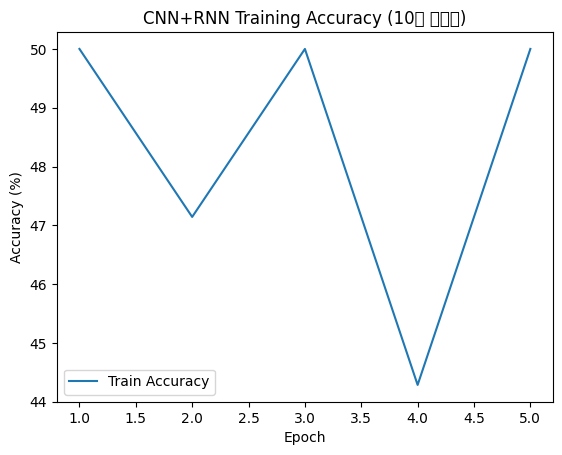

In [16]:
# -------------------------------
# ✅ 학습 정확도 시각화
# -------------------------------
plt.plot(range(1, epochs+1), train_acc_history, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN+RNN Training Accuracy (10초 데이터)")
plt.legend()
plt.show()